<a href="https://colab.research.google.com/github/BartolomeoML/Lesson_10/blob/main/Lesson_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
'''
Загрузка датасета
'''

import pandas as pd

def load_data(url: str) -> pd.DataFrame:
    print("Начало загрузки данных...")
    df = pd.read_csv(url)
    print("Данные успешно загружены!\n")

    rows, cols = df.shape
    print(f"--- Общая информация ---")
    print(f"Количество строк (объявлений): {rows:,}")
    print(f"Количество колонок: {cols}")
    print("-" * 30)

    df.info()
    return df

# Ссылка на датасет
DATA_URL = "https://raw.githubusercontent.com/BartolomeoML/Lesson_10/refs/heads/main/Car_details_v3.csv"

try:
    cars_df = load_data(DATA_URL)
except Exception as e:
    print(f"Ошибка при загрузке: {e}")
    cars_df = None

Начало загрузки данных...
Данные успешно загружены!

--- Общая информация ---
Количество строк (объявлений): 8,128
Количество колонок: 13
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [5]:
'''
Предобработка данных
'''

import pandas as pd
import numpy as np
import re

def preprocess_cardekho_max_variance(df: pd.DataFrame) -> pd.DataFrame:
    print("Начало подготовки...")
    df_clean = df.copy().drop_duplicates()

    # Получаем числовые значение из смешанных строк. errors='coerce' - заменяет на пустоту, если не было числовых данных, а только текст
    for col in ['mileage', 'engine', 'max_power']:
        df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.split(' ').str[0], errors='coerce')
        df_clean[col] = df_clean[col].replace(0.0, np.nan) # Заменяем нули на NaN

    def parse_torque(torque_str):
        '''
        Приводим значения вида "190Nm@ 2000rpm", "22.4 kgm at 1750" из колонки torque к единому числовому виду мощности,
        т.к. деревья не работать с текстом
        '''
        if pd.isna(torque_str): return np.nan
        torque_str = str(torque_str).lower().replace(',', '')
        match = re.search(r'([0-9\.]+)', torque_str)
        if match:
            try:
                val = float(match.group(1))
                if 'kgm' in torque_str: val *= 9.8
                return val if val <= 1000 else np.nan
            except: return np.nan
        return np.nan

    df_clean['torque_nm'] = df_clean['torque'].apply(parse_torque)

    # Удаляем строки без данных в колонках из списка
    critical_cols = ['selling_price', 'year', 'engine', 'max_power', 'seats']
    df_clean = df_clean.dropna(subset=critical_cols)

    # Выделяем марку авто для страховки
    df_clean['brand'] = df_clean['name'].apply(lambda x: str(x).lower().strip().split()[0])

    # Заполнение пропусков. Ранее заменённые нули на NaN заменяем медианными значениями,
    # но не всего датасета, а исходя из значений у каждого бренда авто
    df_clean['mileage'] = df_clean.groupby('brand')['mileage'].transform(lambda x: x.fillna(x.median()))
    df_clean['mileage'] = df_clean['mileage'].fillna(df_clean['mileage'].median())

    df_clean['torque_nm'] = df_clean.groupby('brand')['torque_nm'].transform(lambda x: x.fillna(x.median()))
    df_clean['torque_nm'] = df_clean['torque_nm'].fillna(df_clean['torque_nm'].median())

    # Высчитывам возраст машины, вместо использования года выпуска. Датасет составлен в 2020 году, оттуда и отталкиваемся
    df_clean['car_age'] = 2020 - df_clean['year'].astype(int)

    # Рассчёт эффективности двигателя (сколько л.с. на литр объёма). 0.0001 для страховки от деления на ноль
    df_clean['power_per_liter'] = df_clean['max_power'] / ((df_clean['engine'] / 1000) + 0.0001)

    # Оставляем полное имя машины без изменений (без деления на слова), чтобы XGBoost выучил все.
    # Использование astype('category') говорит алгоритму: "Это текст. Под капотом сам сгруппируй эти текстовые значения в корзины
    # так, чтобы они лучше всего предсказывали цену". Это экономит память и позволяет находить неочевидные связи
    df_clean['full_name'] = df_clean['name'].astype(str).str.lower().str.strip()

    # В датасете количество владельцев записано текстом, поэтому переводим в числа в соответствии со словарём.
    # Если информации о владельце не было, заменяем на единицу
    owner_map = {'first owner': 1, 'second owner': 2, 'third owner': 3, 'fourth & above owner': 4, 'test drive car': 0}
    df_clean['owner'] = df_clean['owner'].astype(str).str.lower().str.strip().map(owner_map).fillna(1)

    # Приводим к единому нижнему регистру для исключения возможных разностей в написании
    for col in ['fuel', 'seller_type', 'transmission']:
        df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()

    # Конвертируем в нативные категории XGBoost
    # astype('category') указывает pandas изменить внутренний тип ячейки данных с "Текст" на "Категория"
    cat_cols = ['full_name', 'brand', 'fuel', 'seller_type', 'transmission']
    for col in cat_cols:
        df_clean[col] = df_clean[col].astype('category')

    # Составляем список важных и нужных колонок после всех преобразований и переименований, которые пойдут в обучение
    cols_to_keep = ['selling_price', 'car_age', 'km_driven', 'mileage', 'engine',
                    'max_power', 'torque_nm', 'power_per_liter', 'seats',
                    'full_name', 'brand', 'fuel', 'seller_type', 'transmission', 'owner']
    df_clean = df_clean[cols_to_keep]

    print(f"Итоговый датасет: {df_clean.shape}")
    return df_clean

if cars_df is not None:
    df_reg = preprocess_cardekho_max_variance(cars_df)

Начало подготовки...
Итоговый датасет: (6717, 15)


In [6]:
'''
Разделение
'''

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

'''
StandardScaler вычитает из колонки среднее значение и делит на отклонение

fit (высчитывает): алгоритм проходит по обучающей выборке и высчитывает
среднее значение и стандартное отклонение для каждой колонки.

transform (вычитает и делит): алгоритм берет каждое конкретное значение,
вычитает из него посчитанное ранее среднее и делит на отклонение.
'''

X = df_reg.drop(columns=['selling_price'])
y = df_reg['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

# Список колонок с числовыми данными
num_cols = ['car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'torque_nm', 'power_per_liter', 'seats', 'owner']

# Для защиты исходных данных от случайного изменения во время предобработки используем копии объектов
X_train = X_train.copy()
X_test = X_test.copy()

# Работаем с ранее определёнными числовыми колонками, текстовые остаются нетронутыми
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (5373, 14)
Размер тестовой выборки: (1344, 14)


In [8]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.1 MB/s eta 0:00:00


In [9]:
'''
Подбор гиперпараметров
'''

import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import warnings
import numpy as np

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        # Задаём дипазон для выбора количества деревьев. Задаём много, т.к. имеется регуляризация и задан параметр min_child_weight
        'n_estimators': trial.suggest_int('n_estimators', 400, 1000),

        # Обычное значение параметра max_depth равно 4-8, чтобы модель не переобучилась, но мы имеем большое количество
        # уникальных комплектаций, поэтому, чтобы алгоритм увидел самые уникальные в глубине, увеличиваем значение до 8-16
        'max_depth': trial.suggest_int('max_depth', 8, 16),

        # Активация подбора в логарифмическом масштабе, для равномерного перебора значений и увеличения скорости обучения.
        # learning_rate умножает предсказание каждого дерева на число из заданного диапазона, т.о.
        # каждое дерево вносит лишь микроскопический вклад, а чтобы цена сильно изменилась, с этим должны согласиться множество деревьев.
        # Одно дерево, зазубрившее выброс, ничего не испортит
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),

        # Линейный поиск без log, т.к. здесь важна равномерность.
        # subsample - доля строк, которые берутся для каждого дерева. Значение 0.7–0.8 сильно борется с переобучением.
        # Каждое новое дерево строиться не на всей таблице, а только на случайных 70-90% машин, что не даёт зацикливаться
        # на одних и тех же специфических примерах
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),

        # Линейный поиск без log, т.к. здесь важна равномерность.
        # Значение 0.6–0.8 заставляет деревья быть более разнообразными.
        # Перед построением, каждое дерево видит разный набор признаков, чтобы искать скрытые закономерности
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

        # Оберегаем модель от переобучения, указывая, чтобы она не создавала новую ветку, если в корзине меньше X машин
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 3),

        # Случайность выборки
        'random_state': 42,

        # Поддержка категориальных признаков
        'enable_categorical': True,

        # Гистограммный метод для ускорения
        'tree_method': 'hist'
    }

    model = XGBRegressor(**params)

    # Основная стоимость авто сосредоточена в районе 200-500 тысяч, но также имеется пласт стоимостью от 500 тысяч до 10 млн.
    # Чтобы не было такого разброса и смещения и минимизации ошибки MSE, с помощью логарифма превращаем значения стоимости в числа
    # небольшим смещением (11, 13, 16)
    y_train_log = np.log1p(y_train)
    score = cross_val_score(model, X_train, y_train_log, cv=4, scoring='r2', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
print("Запуск оптимизации...")
study.optimize(objective, n_trials=30)

print("\n=== Лучшие гиперпараметры от Optuna ===")
print(study.best_params)

Запуск оптимизации...

=== Лучшие гиперпараметры от Optuna ===
{'n_estimators': 889, 'max_depth': 8, 'learning_rate': 0.010610412978839693, 'subsample': 0.8804599241694931, 'colsample_bytree': 0.6816046090231952, 'min_child_weight': 2}


In [10]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

best_params = study.best_params
best_params['random_state'] = 42
best_params['enable_categorical'] = True
best_params['tree_method'] = 'hist'

final_xgb = XGBRegressor(**best_params)

y_train_log = np.log1p(y_train)
final_xgb.fit(X_train, y_train_log)

y_pred_log = final_xgb.predict(X_test)
y_pred = np.expm1(y_pred_log)

final_r2 = r2_score(y_test, y_pred)
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Итоговые метрики XGBoost ===")
print(f"Итоговый R² Score на тесте: {round(final_r2, 4)}")
print(f"Средняя ошибка (MAE): {round(final_mae, 2)} рупий")
print(f"Квадратичная ошибка (RMSE): {round(final_rmse, 2)} рупий")


=== Итоговые метрики XGBoost ===
Итоговый R² Score на тесте: 0.9527
Средняя ошибка (MAE): 65174.82 рупий
Квадратичная ошибка (RMSE): 101913.94 рупий


=== 1. БАЗОВАЯ ИНФОРМАЦИЯ И ПРОПУСКИ ===
Всего строк: 8128
               Пропуски (NaN)  Нулевые значения (0.0)
mileage                   221                       0
engine                    221                       0
max_power                 215                       0
torque                    222                       0
seats                     221                       0
mileage_num               221                      17
engine_num                221                       0
max_power_num             216                      12
car_age                     0                     148
--------------------------------------------------

=== 2. ПРОБЛЕМА РЕДКИХ АВТОМОБИЛЕЙ (ВЫСОКАЯ КАРДИНАЛЬНОСТЬ) ===
Всего уникальных названий машин: 2058
Машин, которые встречаются ровно 1 раз: 823 шт. (40.0% от всех названий!)
Машин, которые встречаются менее 5 раз: 1651 шт. (80.2% от всех названий!)
--------------------------------------------------

=== 3. АНАЛИЗ ВЫБРОСОВ В ЦЕНЕ (ПЕРЕКОС ТАРГЕТА

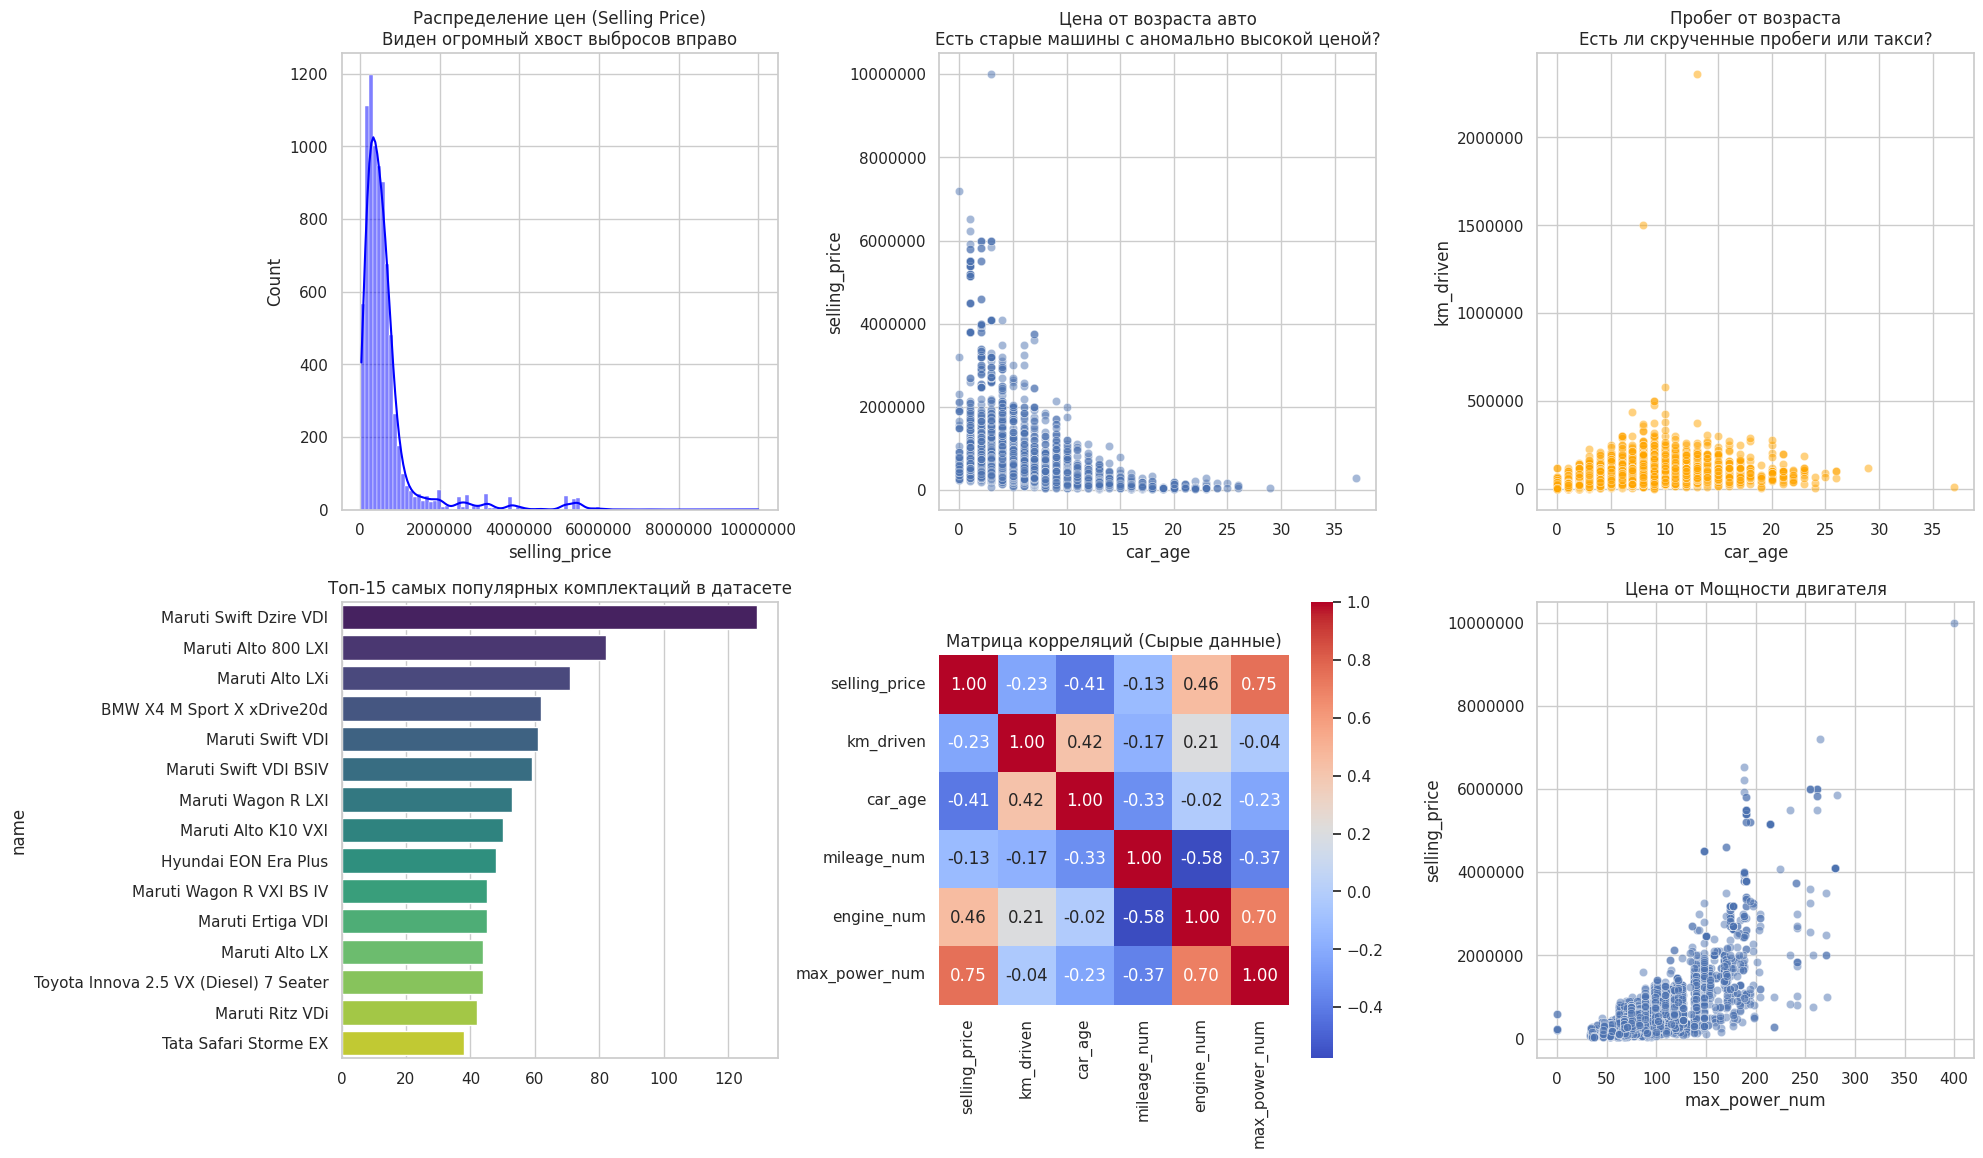


=== 4. ПРИМЕРЫ АНОМАЛЬНЫХ СТРОК ===
                                                   name  year  km_driven  \
644   Tata Indica Vista Aura Safire Anniversary Edition  2009      28900   
785                              Hyundai Santro Xing GL  2009      90000   
1649                             Hyundai Santro Xing GL  2008     128000   
1676                Mercedes-Benz M-Class ML 350 4Matic  2011     110000   
1810                             Mahindra XUV500 W6 2WD  2012    1500000   

      selling_price    mileage  
644          135000   0.0 kmpl  
785          120000   0.0 kmpl  
1649         105000   0.0 kmpl  
1676        1700000   0.0 kmpl  
1810         500000  15.1 kmpl  


In [14]:
'''
Визуализация исходного датасета
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Загрузка сырых данных
url = "https://raw.githubusercontent.com/BartolomeoML/Lesson_10/refs/heads/main/Car_details_v3.csv"
df_eda = pd.read_csv(url)

print("=== 1. БАЗОВАЯ ИНФОРМАЦИЯ И ПРОПУСКИ ===")
print(f"Всего строк: {len(df_eda)}")

# Быстрая очистка чисел для анализа
df_eda['mileage_num'] = pd.to_numeric(df_eda['mileage'].astype(str).str.split(' ').str[0], errors='coerce')
df_eda['engine_num'] = pd.to_numeric(df_eda['engine'].astype(str).str.split(' ').str[0], errors='coerce')
df_eda['max_power_num'] = pd.to_numeric(df_eda['max_power'].astype(str).str.split(' ').str[0], errors='coerce')
df_eda['car_age'] = 2020 - df_eda['year']

# Считаем нули и пропуски
missing_data = pd.DataFrame({
    'Пропуски (NaN)': df_eda.isnull().sum(),
    'Нулевые значения (0.0)': (df_eda == 0).sum() + (df_eda == 0.0).sum()
})
# Отдельно посчитаем нули для mileage (где расход указан как 0.0)
missing_data.loc['mileage_num', 'Нулевые значения (0.0)'] = (df_eda['mileage_num'] == 0.0).sum()
print(missing_data[missing_data.sum(axis=1) > 0])
print("-" * 50)


print("\n=== 2. ПРОБЛЕМА РЕДКИХ АВТОМОБИЛЕЙ (ВЫСОКАЯ КАРДИНАЛЬНОСТЬ) ===")
total_unique_names = df_eda['name'].nunique()
counts = df_eda['name'].value_counts()
rare_1 = (counts == 1).sum()
rare_5 = (counts < 5).sum()

print(f"Всего уникальных названий машин: {total_unique_names}")
print(f"Машин, которые встречаются ровно 1 раз: {rare_1} шт. ({(rare_1/total_unique_names)*100:.1f}% от всех названий!)")
print(f"Машин, которые встречаются менее 5 раз: {rare_5} шт. ({(rare_5/total_unique_names)*100:.1f}% от всех названий!)")
print("-" * 50)


print("\n=== 3. АНАЛИЗ ВЫБРОСОВ В ЦЕНЕ (ПЕРЕКОС ТАРГЕТА) ===")
print(df_eda['selling_price'].describe().apply(lambda x: format(x, 'f')))
print(f"\n99-й перцентиль цены: {df_eda['selling_price'].quantile(0.99):,.0f} рупий")
print(f"Максимальная цена: {df_eda['selling_price'].max():,.0f} рупий")


# === ГРАФИКИ ===
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Распределение цен
sns.histplot(df_eda['selling_price'], bins=100, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Распределение цен (Selling Price)\nВиден огромный хвост выбросов вправо')
axes[0, 0].ticklabel_format(style='plain', axis='x', useOffset=False)

# Цена vs Возраст авто
sns.scatterplot(x='car_age', y='selling_price', data=df_eda, ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Цена от возраста авто\nЕсть старые машины с аномально высокой ценой?')
axes[0, 1].ticklabel_format(style='plain', axis='y', useOffset=False)

# Распределение пробега
sns.scatterplot(x='car_age', y='km_driven', data=df_eda, ax=axes[0, 2], alpha=0.5, color='orange')
axes[0, 2].set_title('Пробег от возраста\nЕсть ли скрученные пробеги или такси?')
axes[0, 2].ticklabel_format(style='plain', axis='y', useOffset=False)

# Топ-15 самых частых машин
top_15 = df_eda['name'].value_counts().head(15)
sns.barplot(y=top_15.index, x=top_15.values, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Топ-15 самых популярных комплектаций в датасете')

# Матрица корреляций
num_cols_raw = ['selling_price', 'km_driven', 'car_age', 'mileage_num', 'engine_num', 'max_power_num']
corr_raw = df_eda[num_cols_raw].corr()

sns.heatmap(corr_raw, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1], square=True)
axes[1, 1].set_title('Матрица корреляций (Сырые данные)')

# График зависимости "Мощность - Цена"
sns.scatterplot(x='max_power_num', y='selling_price', data=df_eda, ax=axes[1, 2], alpha=0.5)
axes[1, 2].set_title('Цена от Мощности двигателя')
axes[1, 2].ticklabel_format(style='plain', axis='y', useOffset=False)

plt.tight_layout()
plt.show()

# Поиск аномалий
print("\n=== 4. ПРИМЕРЫ АНОМАЛЬНЫХ СТРОК ===")
print(df_eda[(df_eda['mileage_num'] == 0.0) | (df_eda['km_driven'] > 500000)].head(5)[['name', 'year', 'km_driven', 'selling_price', 'mileage']])

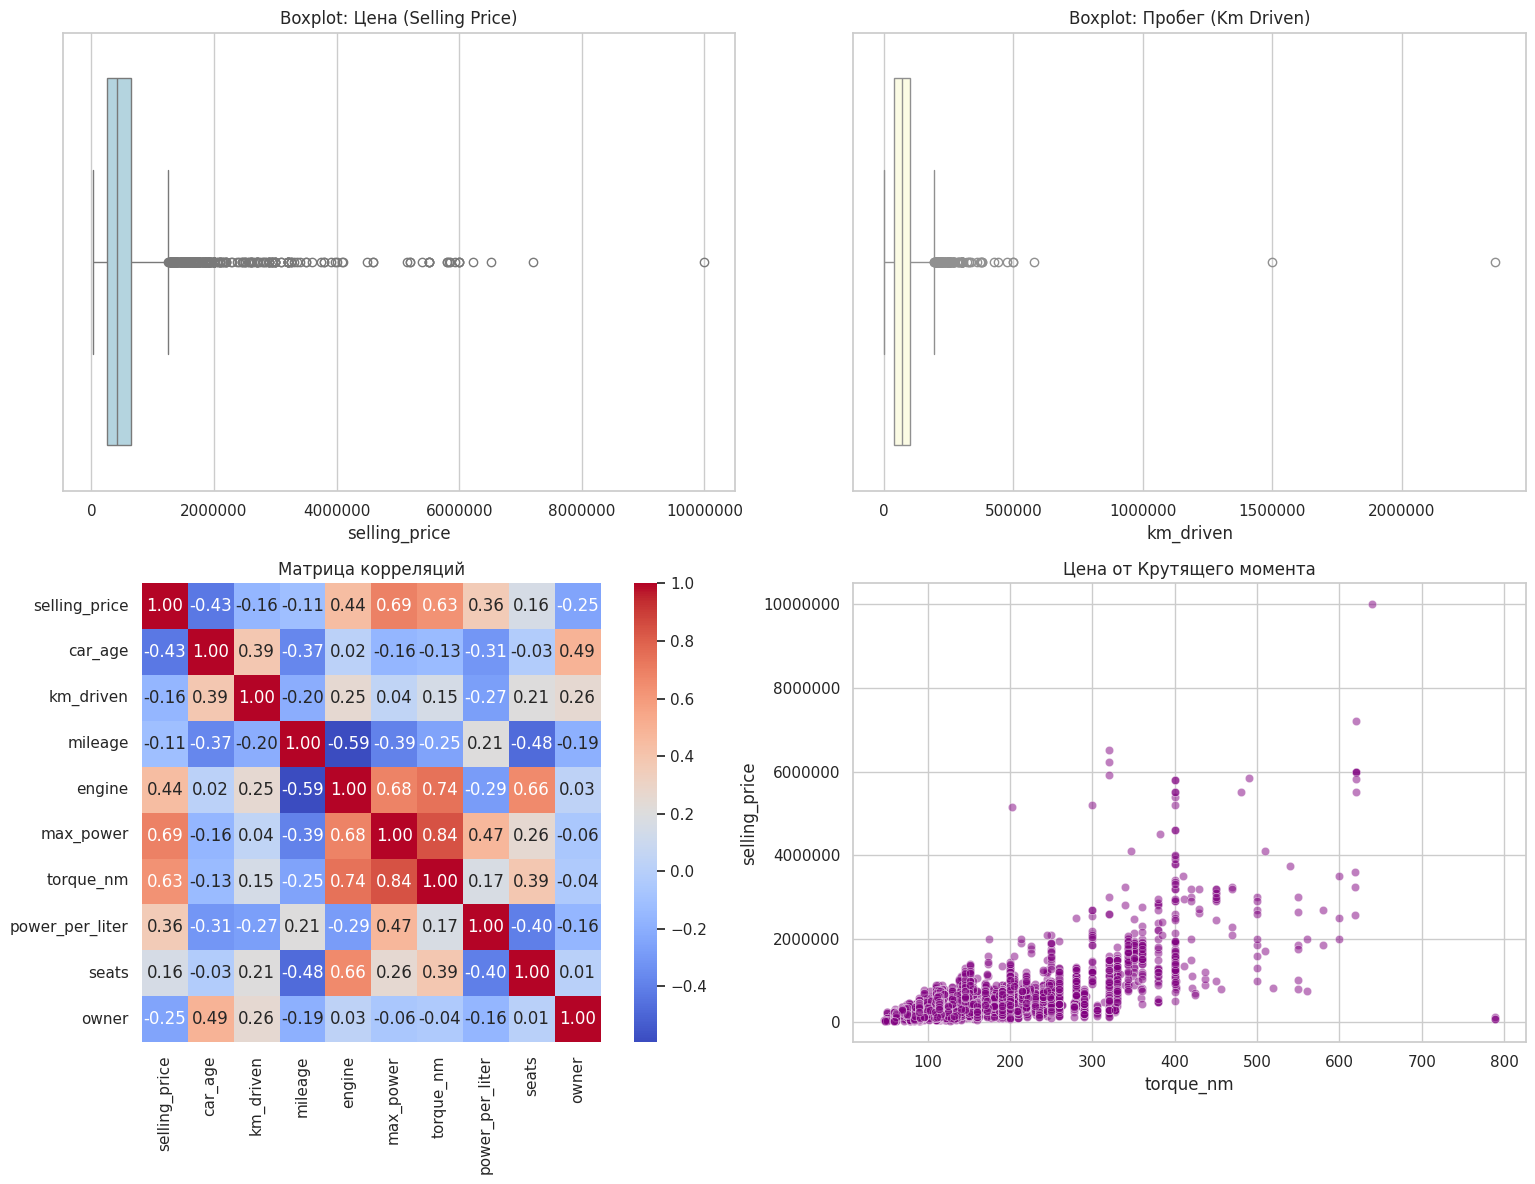

In [17]:
'''
Визуализация итогового датасета
'''

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ящик с усами для Цены (Хвост остался, но он здоровый)
sns.boxplot(x=df_reg['selling_price'], ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Boxplot: Цена (Selling Price)')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# 2. Ящик с усами для Пробега (Адекватный разброс)
sns.boxplot(x=df_reg['km_driven'], ax=axes[0, 1], color='lightyellow')
axes[0, 1].set_title('Boxplot: Пробег (Km Driven)')
axes[0, 1].ticklabel_format(style='plain', axis='x')

# 3. Матрица корреляций (Новые фичи)
# Берем только числовые колонки
num_cols_clean = df_reg.select_dtypes(include=[np.number]).columns
corr_clean = df_reg[num_cols_clean].corr()

sns.heatmap(corr_clean, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0], square=True)
axes[1, 0].set_title('Матрица корреляций')

# 4. Цена от Крутящего момента (Посмотрим, как работает спарсенный torque)
sns.scatterplot(x='torque_nm', y='selling_price', data=df_reg, ax=axes[1, 1], alpha=0.5, color='purple')
axes[1, 1].set_title('Цена от Крутящего момента')
axes[1, 1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()